<a href="https://colab.research.google.com/github/Vedant28082005/CV-2026-H10/blob/main/LAB6/CV_LAB_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import statistics as stats

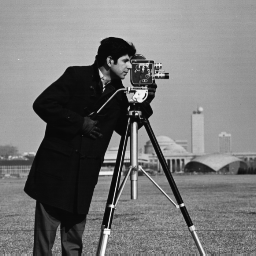

In [2]:
image = cv2.imread("/content/cameraman.png" , cv2.IMREAD_GRAYSCALE)
cv2_imshow(image)

In [17]:
total_pixels = image.shape[0] * image.shape[1]
print(total_pixels)

65536


Otsu Threshold: 89


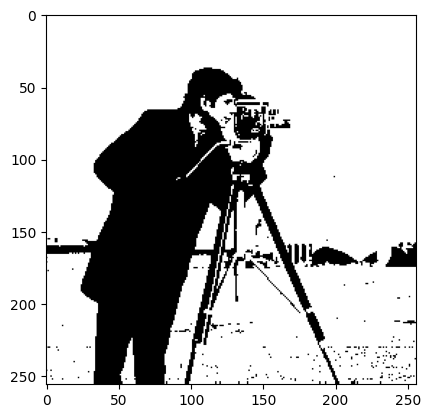

In [41]:
total_pixels = image.size
var_eff_arr = []

for t in range(256):

    c0_arr = []
    c1_arr = []

    for x in range(image.shape[0]):
        for y in range(image.shape[1]):

            if image[x][y] < t:
                c0_arr.append(image[x][y])
            else:
                c1_arr.append(image[x][y])

    prob_c0 = len(c0_arr) / total_pixels
    prob_c1 = len(c1_arr) / total_pixels

    mean_c0 = np.mean(c0_arr) if len(c0_arr) > 0 else 0
    mean_c1 = np.mean(c1_arr) if len(c1_arr) > 0 else 0

    var_eff = prob_c0 * prob_c1 * (mean_c0 - mean_c1) ** 2

    var_eff_arr.append(var_eff)

otsu_threshold = np.argmax(var_eff_arr)

print("Otsu Threshold:", otsu_threshold)

threshold_image = np.where(
    image < otsu_threshold,
    0,
    255
).astype(np.uint8)

plt.imshow(threshold_image, cmap='gray')

[]

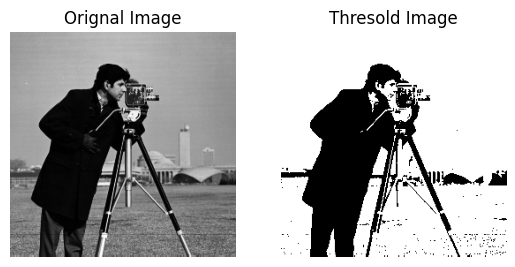

In [47]:
plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Orignal Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(threshold_image, cmap='gray')
plt.title("Thresold Image")
plt.axis('off')

plt.plot()